In [1]:

import anndata as ad
import celltypist
from celltypist import models
import scanpy as sc
import numpy as np
np.random.seed(12)

/data_nfs/og86asub/netmap/netmap-evaluation/netmap/.pixi/envs/default/lib/python3.12/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [2]:
adata = sc.read_h5ad('/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/SRR/kallisto/mtx_conversions/10x_rep2/10x_rep2_cellbender_filter_matrix.h5ad')


In [3]:
adata.var = adata.var.reset_index()
adata.var = adata.var.set_index("gene_symbol")
adata.var.index = adata.var.index.astype(str)
adata.var_names_make_unique()


In [4]:

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

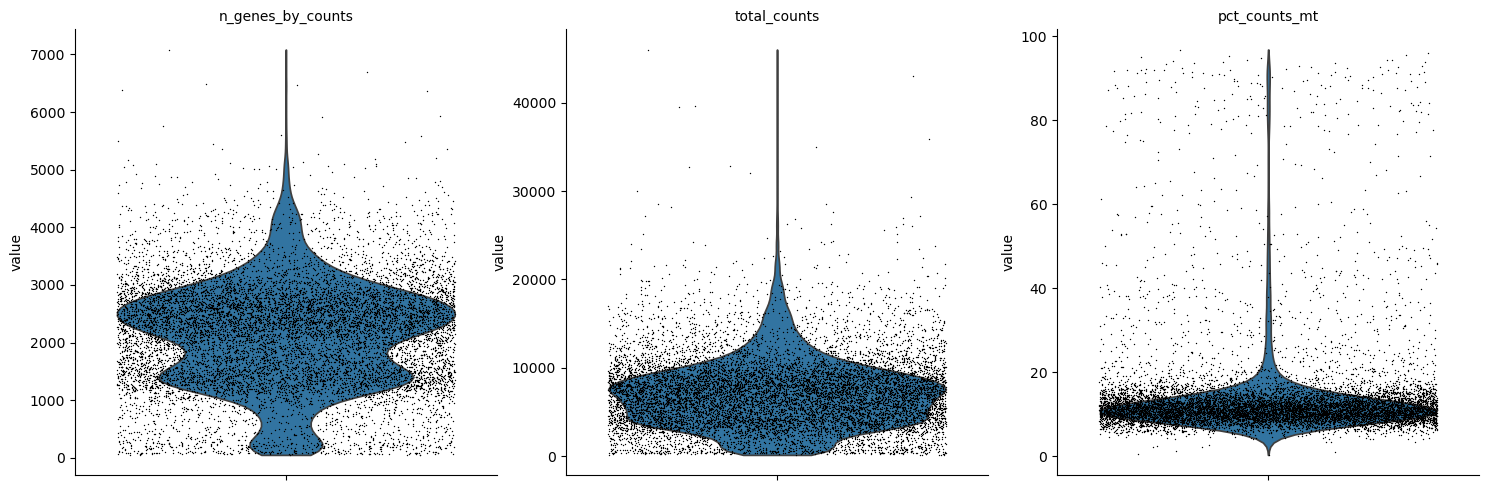

In [5]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

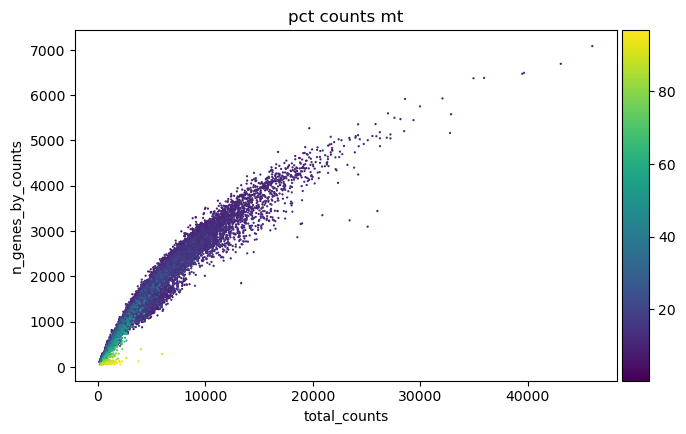

In [6]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [7]:
sc.pp.filter_cells(adata, min_genes=500)
sc.pp.filter_genes(adata, min_cells=50)
adata = adata[adata.obs.pct_counts_mt<20]

In [8]:
sc.pp.scrublet(adata)


In [9]:
adata = adata[adata.obs.predicted_doublet == False]


In [10]:
adata

View of AnnData object with n_obs × n_vars = 10149 × 15392
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'index', 'gene_versions', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scrublet'

In [11]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [12]:
# Normalizing to median total counts
sc.pp.normalize_total(adata, target_sum = 10000)
adata.layers['count_norm'] = adata.X.copy()
# Logarithmize the data
sc.pp.log1p(adata)

In [13]:
models.download_models(model = 'Immune_All_Low.pkl', force_update = True)
model = models.Model.load(model = 'Immune_All_High.pkl')
predictions = celltypist.annotate(adata, model = 'Immune_All_High.pkl', majority_voting = True)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 61
📂 Storing models in /data/og86asub/.celltypist/data/models
💾 Total models to download: 1
💾 Downloading model [1/1]: Immune_All_Low.pkl
🔬 Input data has 10149 cells and 15392 genes
🔗 Matching reference genes in the model
🧬 4485 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


In [14]:
adata = predictions.to_adata()
adata.obs.majority_voting.value_counts()

majority_voting
Monocytes                   7196
T cells                     1516
ILC                          646
DC                           327
pDC                          190
B cells                      187
Megakaryocytes/platelets      60
HSC/MPP                       17
Plasma cells                  10
Name: count, dtype: int64

In [15]:
model = models.Model.load(model = 'Immune_All_Low.pkl')
predictions = celltypist.annotate(adata, model = 'Immune_All_Low.pkl', majority_voting = True)

🔬 Input data has 10149 cells and 15392 genes


🔗 Matching reference genes in the model
🧬 4485 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


In [16]:
adata.obs['granular']= predictions.predicted_labels['predicted_labels']

In [17]:
sc.pp.highly_variable_genes(adata, n_top_genes=2500)

In [ ]:
sc.pp.pca(adata)
sc.pp.neighbors(adata)



In [19]:
sc.tl.umap(adata)


In [28]:
sc.tl.leiden(adata, resolution=0.25)

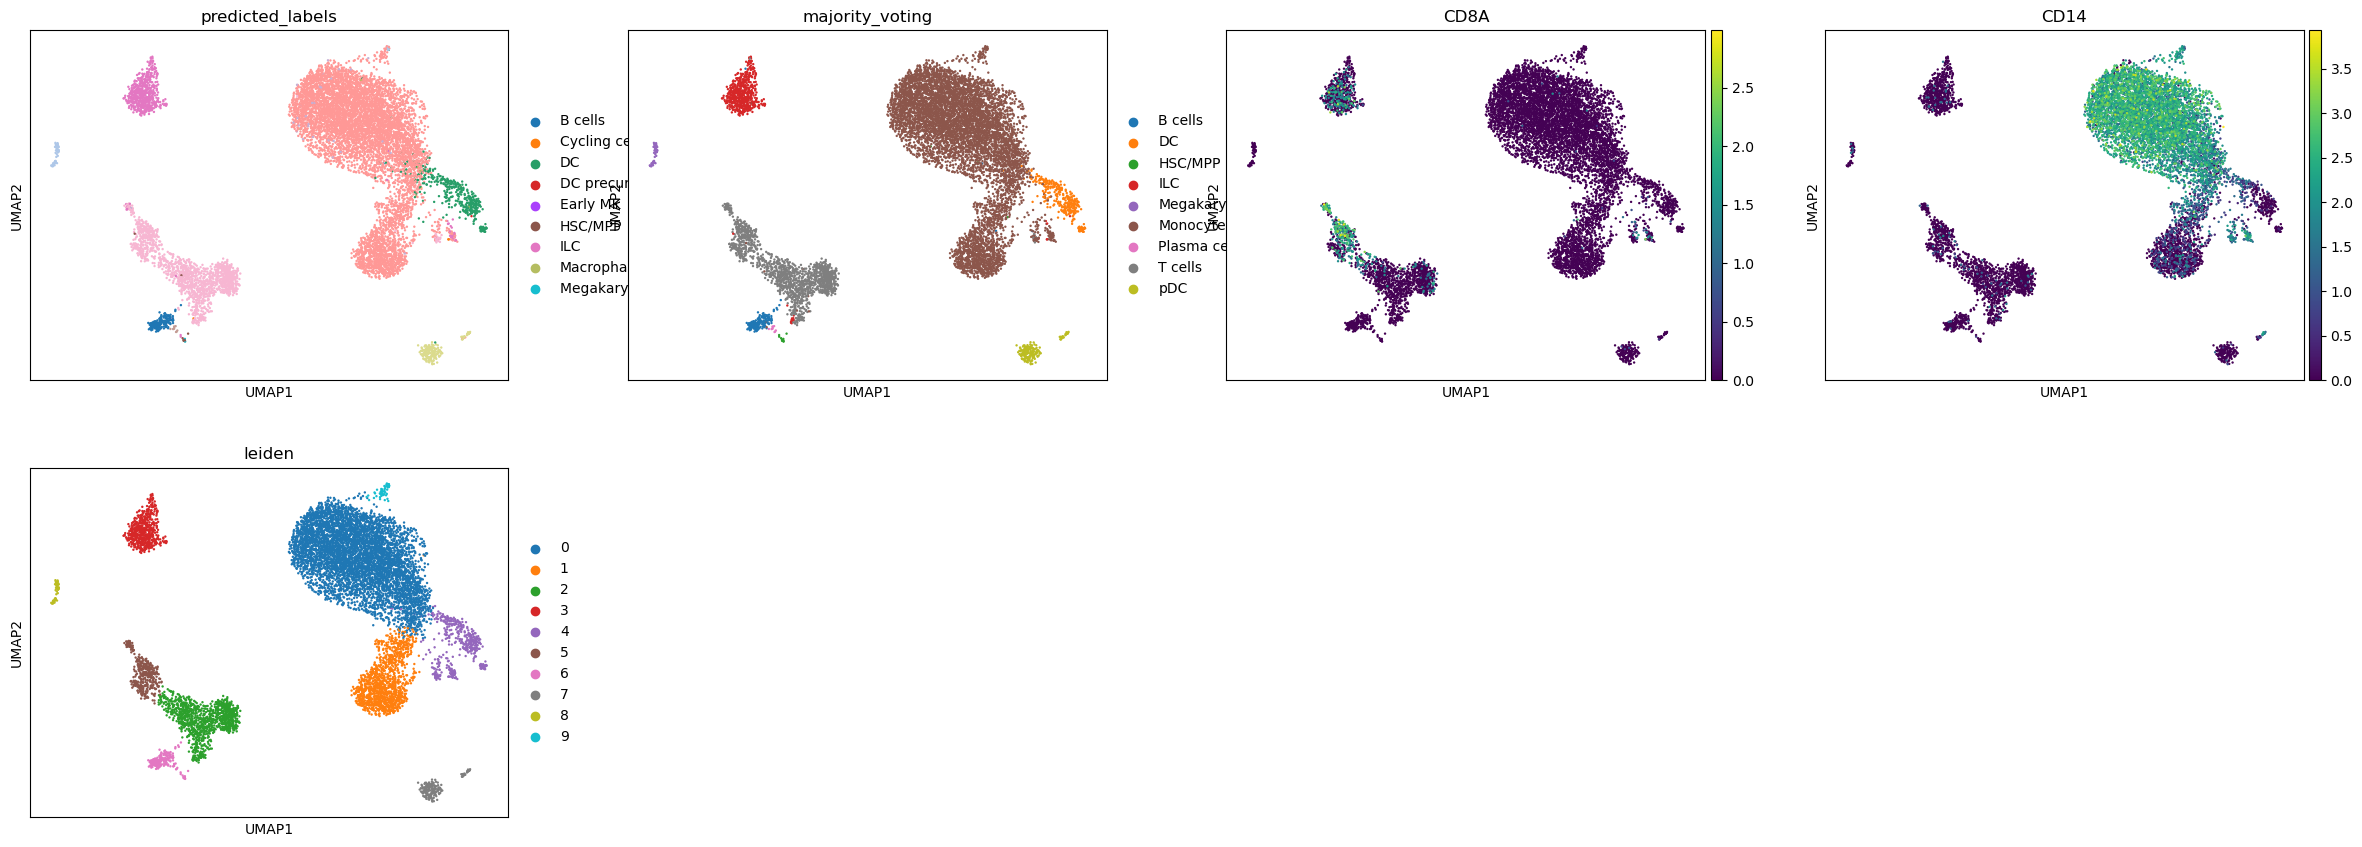

In [29]:
sc.pl.umap(adata, color = [ 'predicted_labels', 'majority_voting', 'CD8A', 'CD14', 'leiden'])

In [30]:
celltype_mapping_2 = {
    '0': 'cd14+_monocytes',
    '1': 'cd14-_monocytes',
    '2':  'cd4+_tcells',
    '3': 'nk_cells',
    '5': 'cd8+_tcells',
    '4': 'DC',
    '6': 'b_cells',
    '7': 'pDC',
    '9': 'cd14+_monocytes',
    '8':  'megakaryocytes',}

In [31]:
adata.obs['celltype_semi_manual'] = [celltype_mapping_2[c] for c in adata.obs['leiden']]

In [33]:
adata = adata[:,adata.var.pct_dropout_by_counts<95].copy()

... storing 'celltype_semi_manual' as categorical


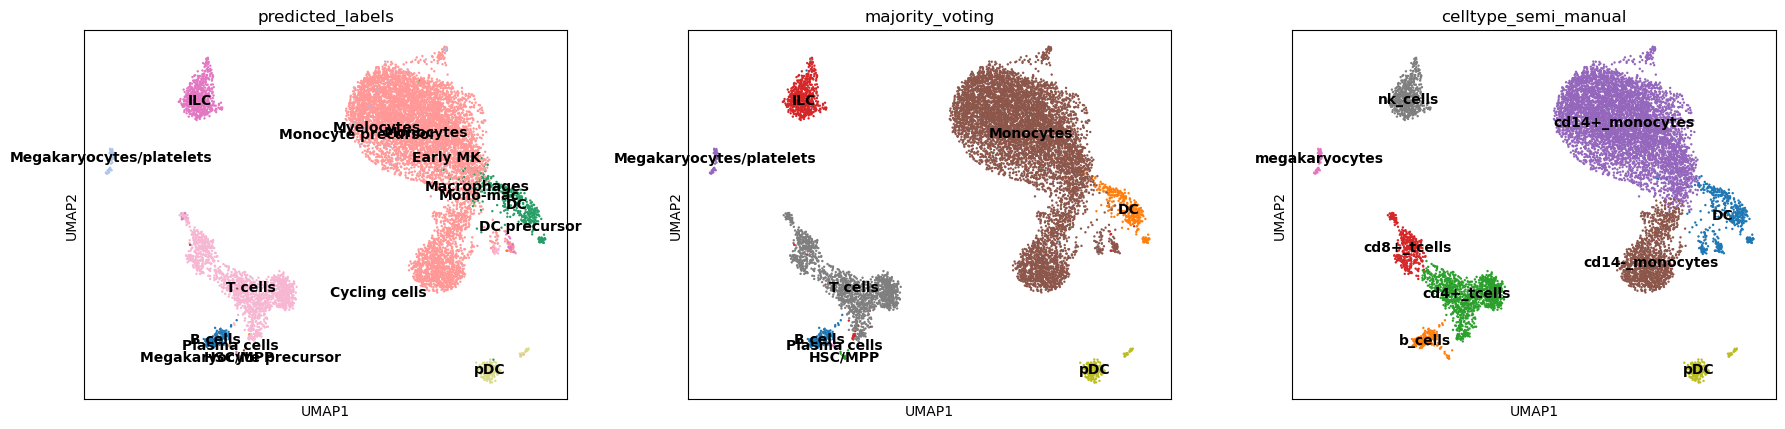

In [32]:
sc.pl.umap(adata, color = [ 'predicted_labels', 'majority_voting', 'celltype_semi_manual'], legend_loc = 'on data')

In [34]:
experiment_id = '10x-rep2-kallisto-cellbender'
output_dir = f'/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/reprocessed/{experiment_id}'
import os
import os.path as op
os.makedirs(output_dir, exist_ok = True)
adata.obs.loc[:, ['celltype_semi_manual']].reset_index().to_csv(op.join(output_dir, 'barcode_annotation.tsv'), sep = '\t')

In [35]:

adata.X = np.nan_to_num(adata.X) 
adata.X[adata.X == np.inf] = 0
adata.X[adata.X == -np.inf] = 0



In [36]:
adata = adata[:, adata.var.highly_variable].copy()

import pandas as pd
pangalao = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/data/markers/panglaodb_human.csv')
high_ui = pangalao[pangalao['UI']>0.1]['Official gene symbol'].values
adata = adata[:, ~adata.var.index.isin(high_ui)].copy()

In [37]:
adata.write_h5ad(op.join(output_dir, f'{experiment_id}-wk.h5ad'))

In [38]:
adata = adata[adata.obs.celltype_semi_manual != 'megakaryocytes'].copy()
adata.write_h5ad(op.join(output_dir, f'{experiment_id}.h5ad'))

In [39]:
adata

AnnData object with n_obs × n_vars = 10089 × 916
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'predicted_labels', 'majority_voting', 'conf_score', 'granular', 'leiden', 'celltype_semi_manual'
    var: 'index', 'gene_versions', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'scrublet', 'log1p', 'neighbors', 'over_clustering', 'hvg', 'pca', 'leiden', 'umap', 'predicted_labels_colors', 'majority_voting_c

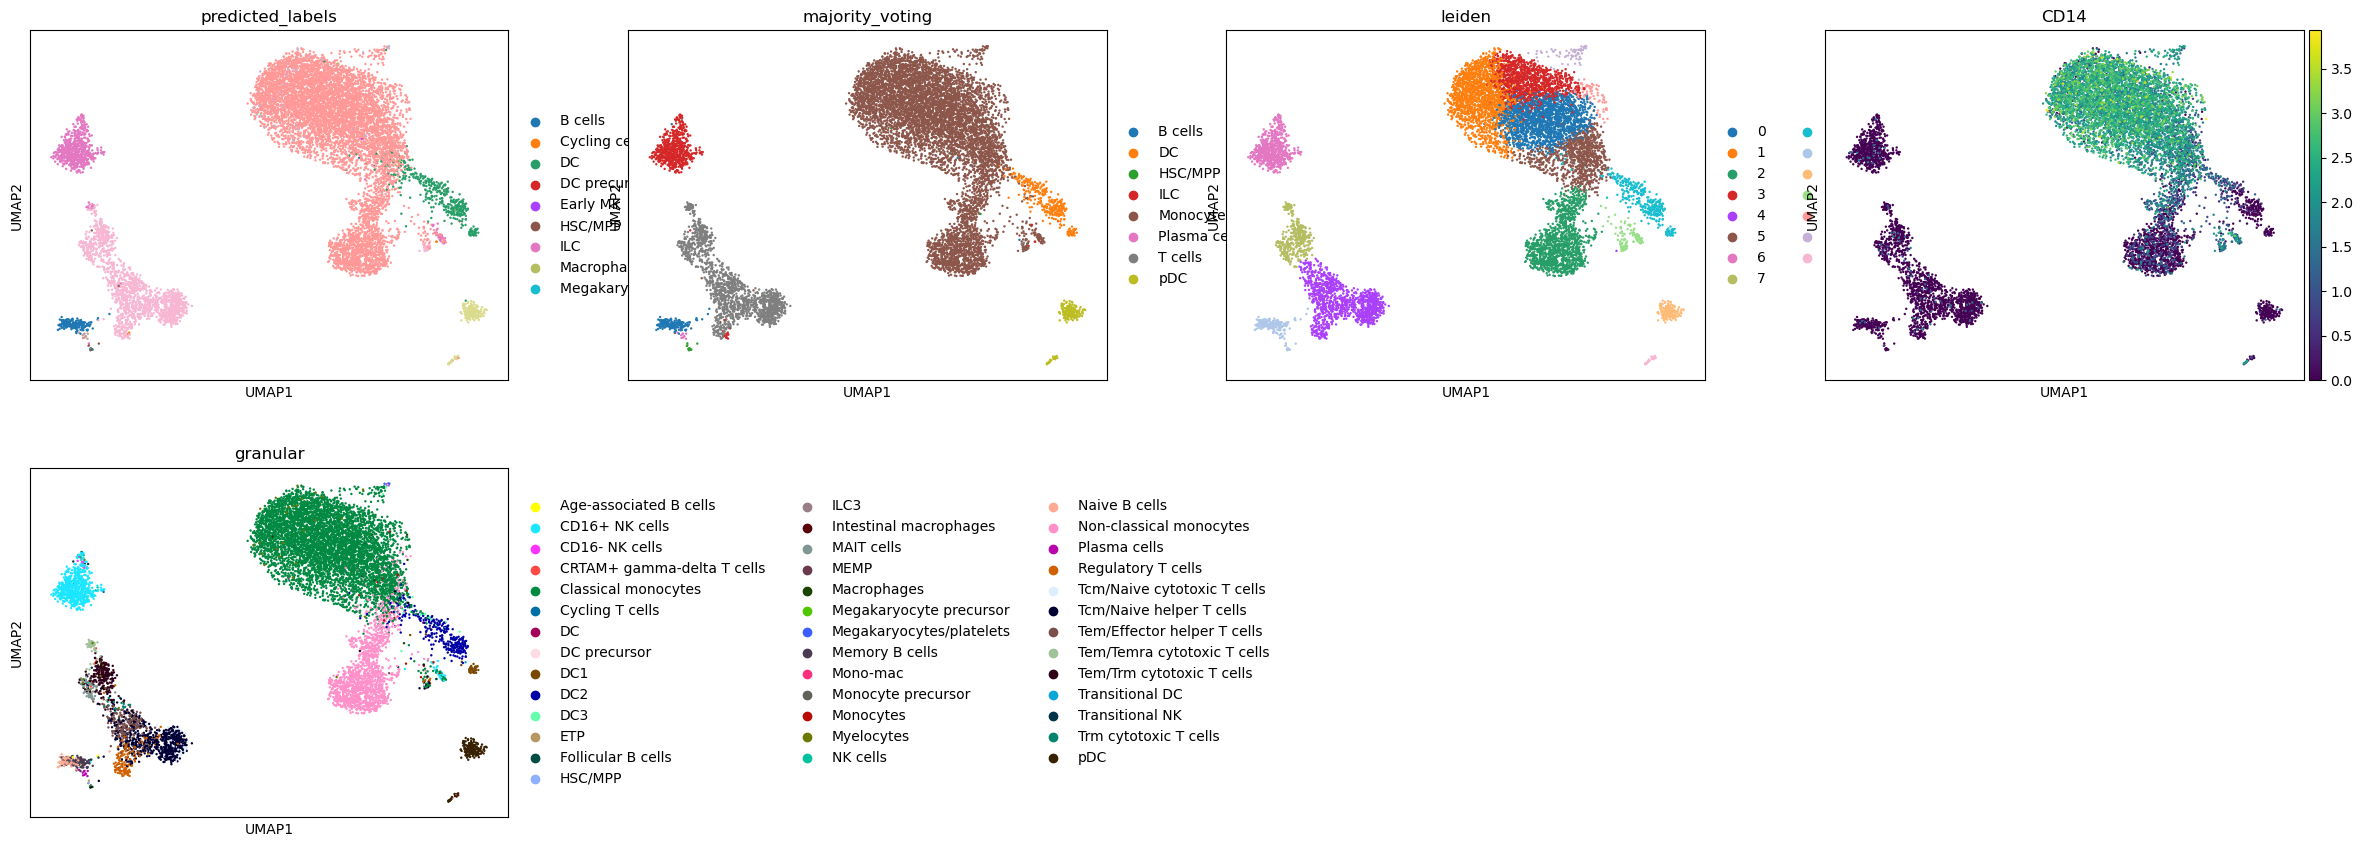

In [ ]:
sc.pl.umap(adata, color = [ 'predicted_labels', 'majority_voting' , 'leiden', 'CD14', 'granular'])